In [3]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configurações
ROP_PATH = '/backup/pedro_fonseca/PATIENT_ROP/DATASET/images_stack_without_captions/images_stack_without_captions/*.jpg'
ORIGA_PATH = '/backup/lucas/datasets/origa/ORIGA/Images/*.jpg'
N_SAMPLES = 500  # Número de imagens por dataset para análise
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 80)
print("ANÁLISE DE COMPATIBILIDADE DE DOMÍNIOS: ROP vs ORIGA")
print("=" * 80)

# 1. Carregar paths das imagens
print("\n[1/6] Carregando paths das imagens...")
rop_images = glob(ROP_PATH)
origa_images = glob(ORIGA_PATH)

print(f"Total ROP images: {len(rop_images)}")
print(f"Total ORIGA images: {len(origa_images)}")

# Amostrar aleatoriamente
n_rop = min(N_SAMPLES, len(rop_images))
n_origa = min(N_SAMPLES, len(origa_images))

rop_sample = np.random.choice(rop_images, n_rop, replace=False)
origa_sample = np.random.choice(origa_images, n_origa, replace=False)

print(f"Usando {n_rop} imagens ROP e {n_origa} imagens ORIGA para análise")

/home/lucas/.conda/envs/notebook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ANÁLISE DE COMPATIBILIDADE DE DOMÍNIOS: ROP vs ORIGA

[1/6] Carregando paths das imagens...
Total ROP images: 6004
Total ORIGA images: 650
Usando 500 imagens ROP e 500 imagens ORIGA para análise



[2/6] Visualizando exemplos de cada dataset...


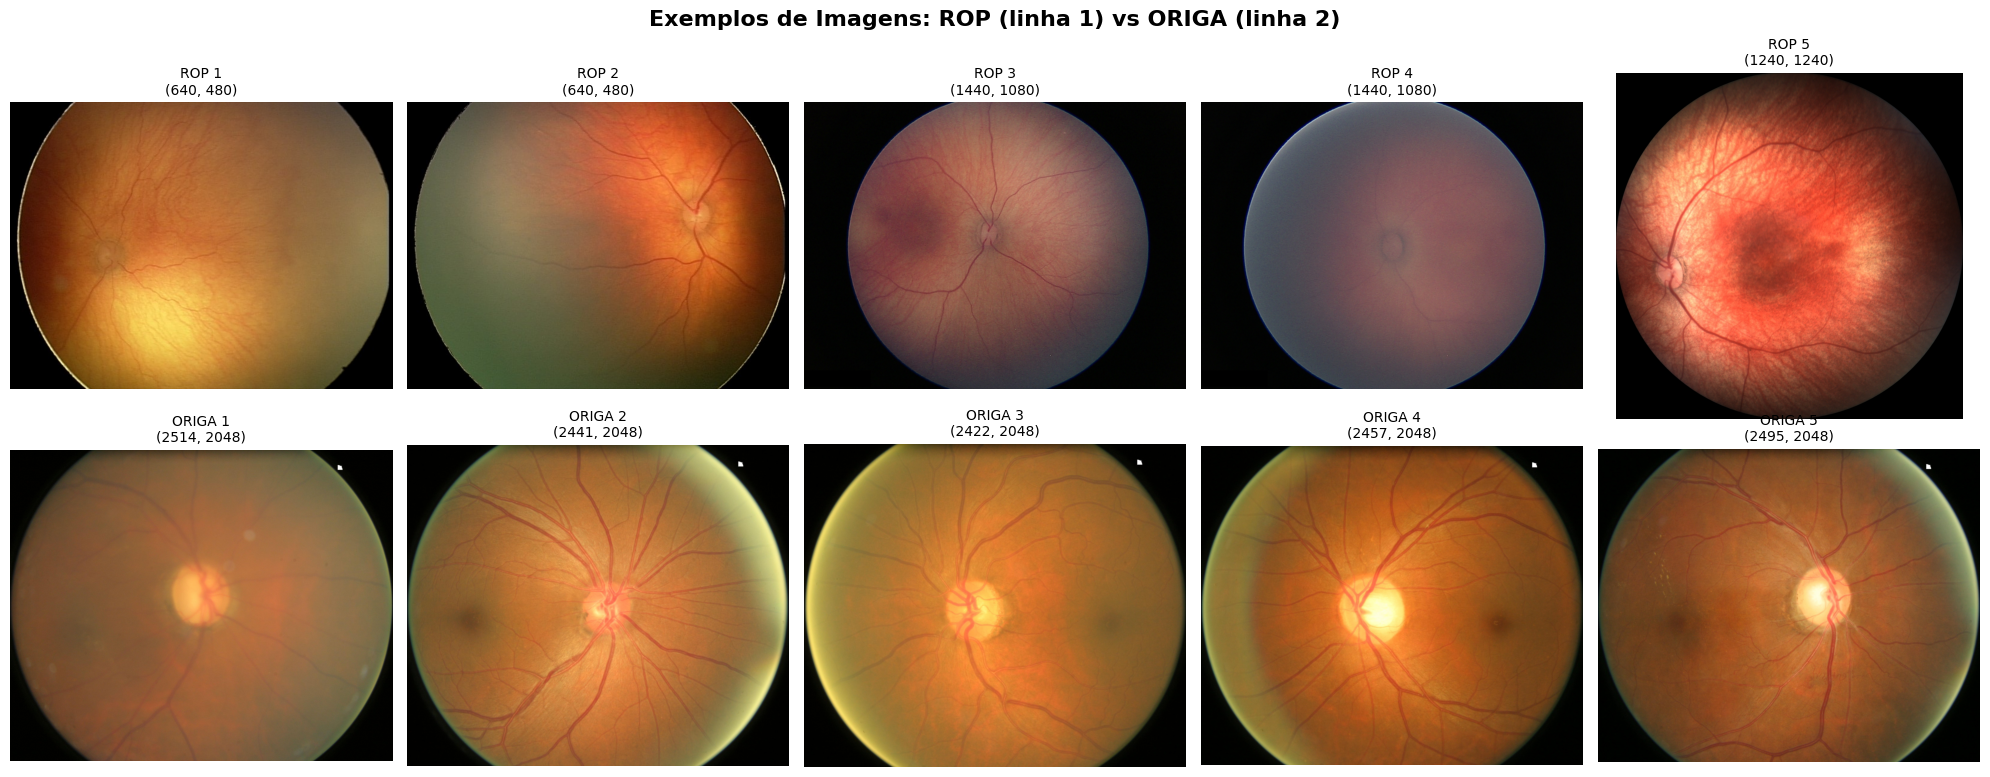

In [4]:
# 2. Visualizar exemplos
print("\n[2/6] Visualizando exemplos de cada dataset...")
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Exemplos de Imagens: ROP (linha 1) vs ORIGA (linha 2)', fontsize=16, fontweight='bold')

for i in range(5):
    # ROP
    img_rop = Image.open(rop_sample[i]).convert('RGB')
    axes[0, i].imshow(img_rop)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'ROP {i+1}\n{img_rop.size}', fontsize=10)
    
    # ORIGA
    img_origa = Image.open(origa_sample[i]).convert('RGB')
    axes[1, i].imshow(img_origa)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'ORIGA {i+1}\n{img_origa.size}', fontsize=10)

plt.tight_layout()
plt.show()



[3/6] Analisando distribuições de intensidade e cores...


Processando: 100%|██████████| 100/100 [00:08<00:00, 12.26it/s]


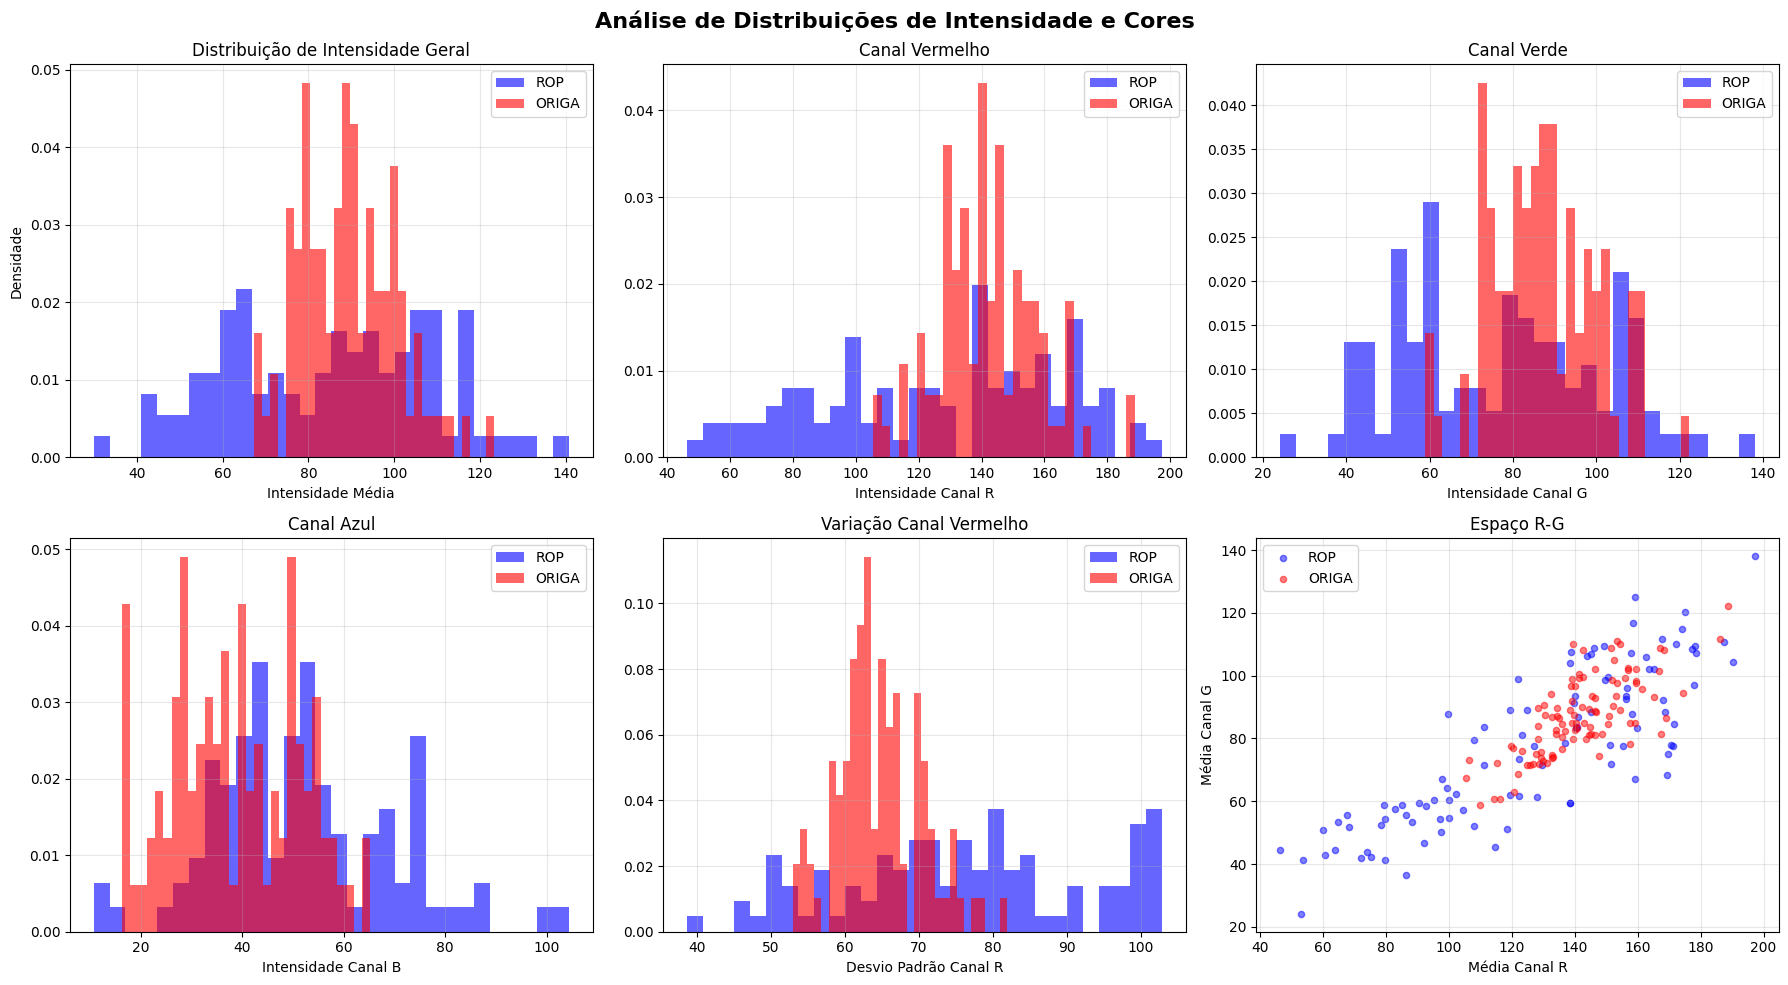


Estatísticas Resumidas:
--------------------------------------------------
ROP - Intensidade média: 85.14 ± 23.86
ORIGA - Intensidade média: 89.16 ± 11.09

ROP - Canal R: 126.44, G: 77.07, B: 51.92
ORIGA - Canal R: 141.93, G: 87.16, B: 38.39


In [5]:
# 3. Análise de distribuição de cores e intensidades
print("\n[3/6] Analisando distribuições de intensidade e cores...")

def compute_image_stats(image_paths, n_samples=100):
    """Calcula estatísticas de cor e intensidade"""
    sample_paths = np.random.choice(image_paths, min(n_samples, len(image_paths)), replace=False)
    
    means_r, means_g, means_b = [], [], []
    stds_r, stds_g, stds_b = [], [], []
    intensities = []
    
    for path in tqdm(sample_paths, desc="Processando"):
        img = np.array(Image.open(path).convert('RGB'))
        
        means_r.append(img[:,:,0].mean())
        means_g.append(img[:,:,1].mean())
        means_b.append(img[:,:,2].mean())
        
        stds_r.append(img[:,:,0].std())
        stds_g.append(img[:,:,1].std())
        stds_b.append(img[:,:,2].std())
        
        intensities.append(img.mean())
    
    return {
        'means_r': means_r, 'means_g': means_g, 'means_b': means_b,
        'stds_r': stds_r, 'stds_g': stds_g, 'stds_b': stds_b,
        'intensities': intensities
    }

stats_rop = compute_image_stats(rop_sample, n_samples=100)
stats_origa = compute_image_stats(origa_sample, n_samples=100)

# Plotar distribuições
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análise de Distribuições de Intensidade e Cores', fontsize=16, fontweight='bold')

# Intensidade geral
axes[0, 0].hist(stats_rop['intensities'], bins=30, alpha=0.6, label='ROP', color='blue', density=True)
axes[0, 0].hist(stats_origa['intensities'], bins=30, alpha=0.6, label='ORIGA', color='red', density=True)
axes[0, 0].set_xlabel('Intensidade Média')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].set_title('Distribuição de Intensidade Geral')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Canal R
axes[0, 1].hist(stats_rop['means_r'], bins=30, alpha=0.6, label='ROP', color='blue', density=True)
axes[0, 1].hist(stats_origa['means_r'], bins=30, alpha=0.6, label='ORIGA', color='red', density=True)
axes[0, 1].set_xlabel('Intensidade Canal R')
axes[0, 1].set_title('Canal Vermelho')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Canal G
axes[0, 2].hist(stats_rop['means_g'], bins=30, alpha=0.6, label='ROP', color='blue', density=True)
axes[0, 2].hist(stats_origa['means_g'], bins=30, alpha=0.6, label='ORIGA', color='red', density=True)
axes[0, 2].set_xlabel('Intensidade Canal G')
axes[0, 2].set_title('Canal Verde')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Canal B
axes[1, 0].hist(stats_rop['means_b'], bins=30, alpha=0.6, label='ROP', color='blue', density=True)
axes[1, 0].hist(stats_origa['means_b'], bins=30, alpha=0.6, label='ORIGA', color='red', density=True)
axes[1, 0].set_xlabel('Intensidade Canal B')
axes[1, 0].set_title('Canal Azul')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Std R
axes[1, 1].hist(stats_rop['stds_r'], bins=30, alpha=0.6, label='ROP', color='blue', density=True)
axes[1, 1].hist(stats_origa['stds_r'], bins=30, alpha=0.6, label='ORIGA', color='red', density=True)
axes[1, 1].set_xlabel('Desvio Padrão Canal R')
axes[1, 1].set_title('Variação Canal Vermelho')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Comparação RGB
axes[1, 2].scatter(stats_rop['means_r'], stats_rop['means_g'], alpha=0.5, label='ROP', color='blue', s=20)
axes[1, 2].scatter(stats_origa['means_r'], stats_origa['means_g'], alpha=0.5, label='ORIGA', color='red', s=20)
axes[1, 2].set_xlabel('Média Canal R')
axes[1, 2].set_ylabel('Média Canal G')
axes[1, 2].set_title('Espaço R-G')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas numéricas
print("\nEstatísticas Resumidas:")
print("-" * 50)
print(f"ROP - Intensidade média: {np.mean(stats_rop['intensities']):.2f} ± {np.std(stats_rop['intensities']):.2f}")
print(f"ORIGA - Intensidade média: {np.mean(stats_origa['intensities']):.2f} ± {np.std(stats_origa['intensities']):.2f}")
print(f"\nROP - Canal R: {np.mean(stats_rop['means_r']):.2f}, G: {np.mean(stats_rop['means_g']):.2f}, B: {np.mean(stats_rop['means_b']):.2f}")
print(f"ORIGA - Canal R: {np.mean(stats_origa['means_r']):.2f}, G: {np.mean(stats_origa['means_g']):.2f}, B: {np.mean(stats_origa['means_b']):.2f}")

In [6]:
# 4. Extração de features com ResNet50 pré-treinado
print("\n[4/6] Extraindo features com ResNet50...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

# Carregar modelo
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remover FC layer
model = model.to(device)
model.eval()

# Transformações
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(image_paths, model, transform, device):
    """Extrai features de imagens"""
    features = []
    
    with torch.no_grad():
        for path in tqdm(image_paths, desc="Extraindo features"):
            try:
                img = Image.open(path).convert('RGB')
                img_tensor = transform(img).unsqueeze(0).to(device)
                feat = model(img_tensor)
                features.append(feat.cpu().numpy().flatten())
            except Exception as e:
                print(f"Erro ao processar {path}: {e}")
                continue
    
    return np.array(features)

# Extrair features (usar menos amostras para velocidade)
n_vis = min(300, n_rop, n_origa)
rop_vis_sample = np.random.choice(rop_sample, n_vis, replace=False)
origa_vis_sample = np.random.choice(origa_sample, n_vis, replace=False)

features_rop = extract_features(rop_vis_sample, model, transform, device)
features_origa = extract_features(origa_vis_sample, model, transform, device)

print(f"Features ROP shape: {features_rop.shape}")
print(f"Features ORIGA shape: {features_origa.shape}")


[4/6] Extraindo features com ResNet50...
Usando device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/lucas/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%
Extraindo features: 100%|██████████| 300/300 [00:23<00:00, 12.78it/s]

Features ROP shape: (300, 2048)
Features ORIGA shape: (300, 2048)



[5/6] Gerando visualização t-SNE...
Variância explicada por 50 componentes PCA: 89.04%
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 600 samples in 0.000s...
[t-SNE] Computed neighbors for 600 samples in 0.082s...
[t-SNE] Computed conditional probabilities for sample 600 / 600
[t-SNE] Mean sigma: 3.364289
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.541851
[t-SNE] KL divergence after 1000 iterations: 0.829865


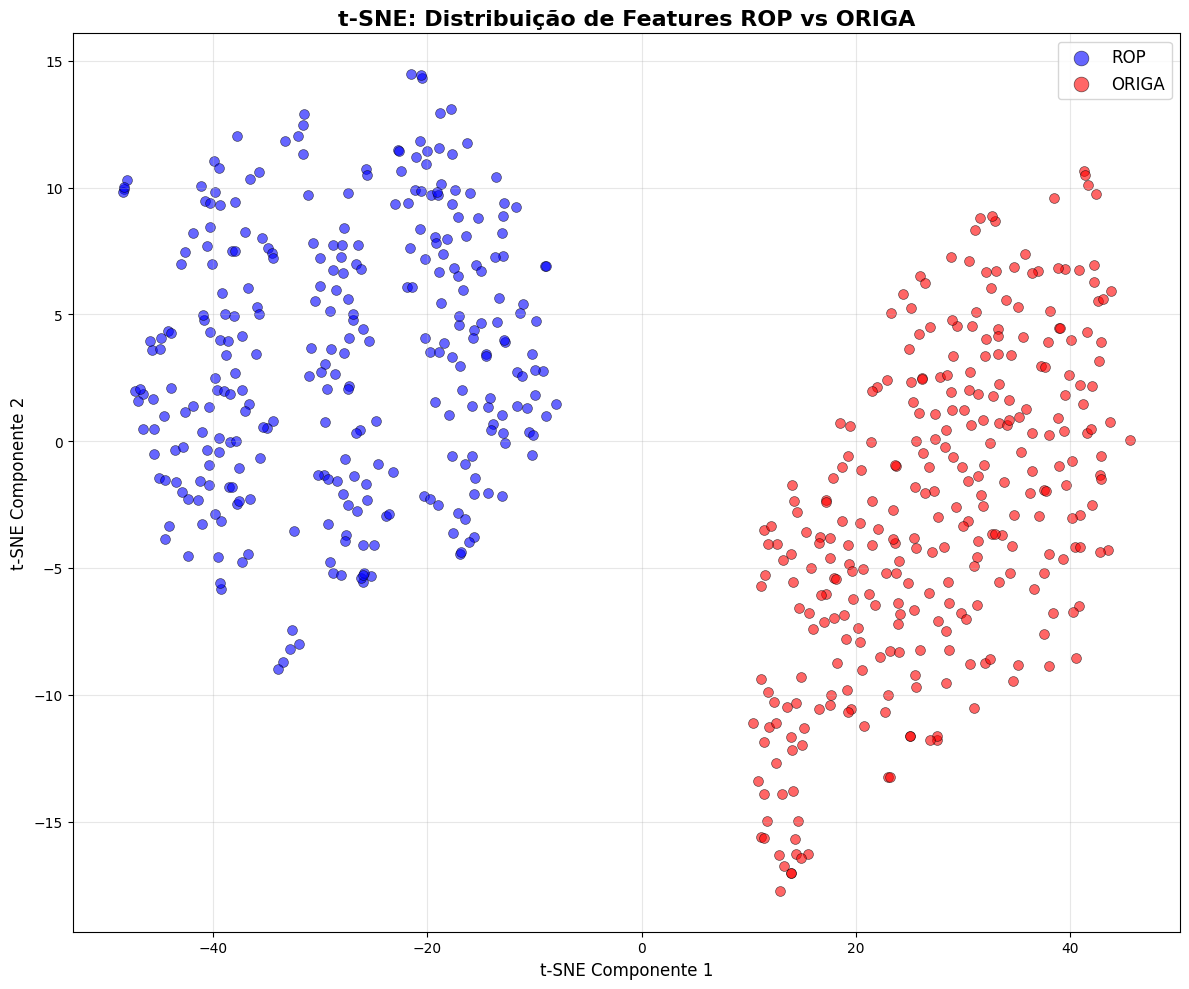

In [9]:
# 5. Visualização t-SNE
print("\n[5/6] Gerando visualização t-SNE...")
all_features = np.vstack([features_rop, features_origa])
labels = np.array([0] * len(features_rop) + [1] * len(features_origa))

# PCA primeiro para reduzir dimensionalidade
pca = PCA(n_components=50, random_state=SEED)
features_pca = pca.fit_transform(all_features)
print(f"Variância explicada por 50 componentes PCA: {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000, verbose=1)
embedded_tsne = tsne.fit_transform(features_pca)

# Plot t-SNE
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
scatter1 = ax.scatter(embedded_tsne[labels == 0, 0], 
                      embedded_tsne[labels == 0, 1],
                      c='blue', label='ROP', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
scatter2 = ax.scatter(embedded_tsne[labels == 1, 0], 
                      embedded_tsne[labels == 1, 1],
                      c='red', label='ORIGA', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
ax.set_title('t-SNE: Distribuição de Features ROP vs ORIGA', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE Componente 1', fontsize=12)
ax.set_ylabel('t-SNE Componente 2', fontsize=12)
ax.legend(fontsize=12, markerscale=1.5)
ax.grid(alpha=0.3)
plt.tight_layout()


[6/6] Gerando visualização UMAP...


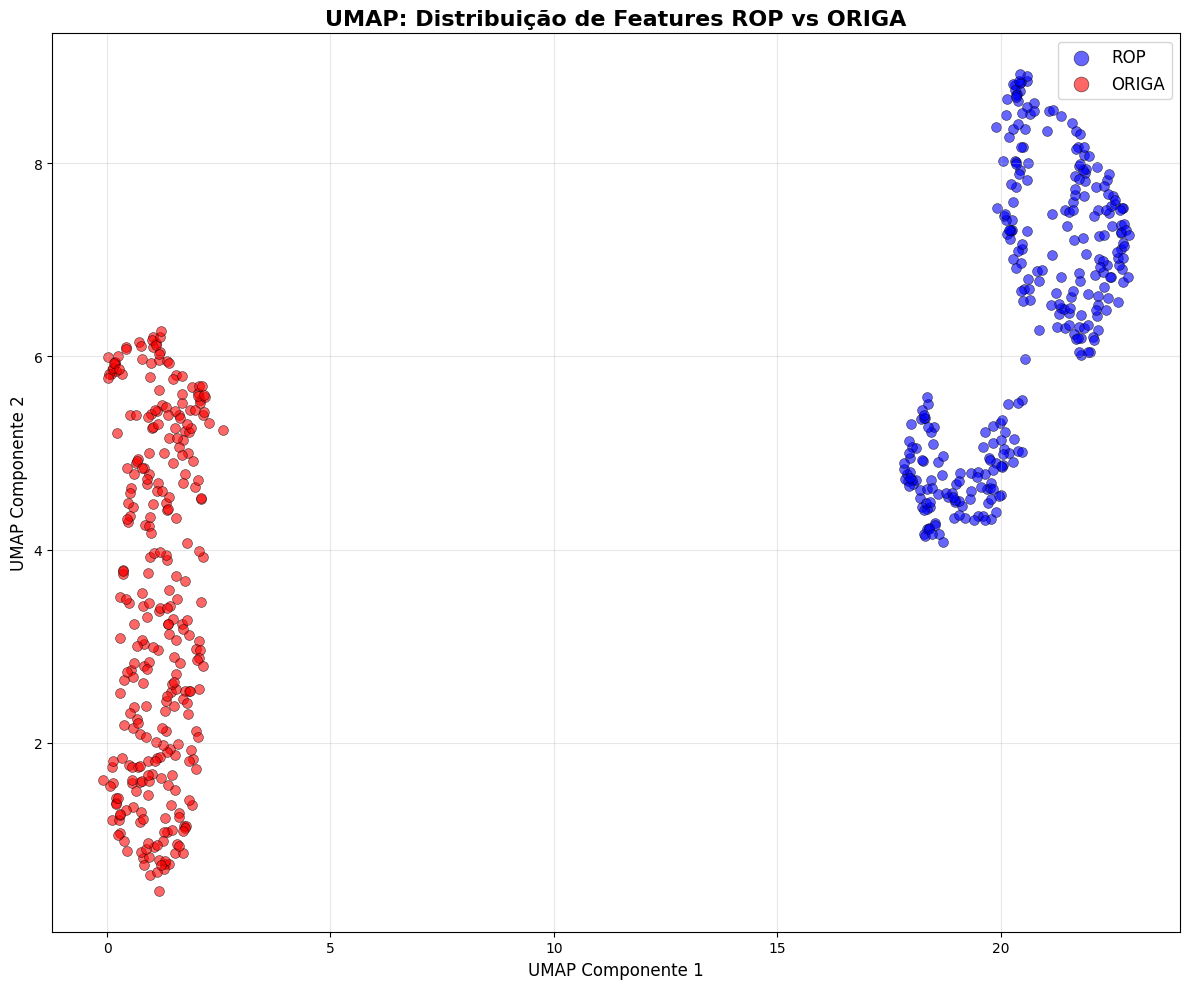


INTERPRETAÇÃO DOS RESULTADOS:

1. Visualização de Exemplos: Observe diferenças em FOV, qualidade, anatomia

2. Distribuições de Cores/Intensidades:
   - Distribuições similares = domínios mais próximos
   - Distribuições muito diferentes = domínios distantes

3. t-SNE e UMAP:
   - CLUSTERS MISTURADOS = Boa compatibilidade para domain adaptation
   - CLUSTERS SEPARADOS = Domínios muito diferentes, DA pode ser desafiador
   - SOBREPOSIÇÃO PARCIAL = DA pode funcionar, mas requer técnicas robustas

Se os clusters estiverem completamente separados no t-SNE/UMAP, considere:
- Transfer learning simples em vez de domain adaptation complexa
- Pré-treino em datasets gerais de retina (EyePACS, Messidor)
- Técnicas de domain adaptation mais agressivas (DANN, CORAL, etc.)



In [8]:
# 6. Visualização UMAP (mais rápido e preserva estrutura global)
print("\n[6/6] Gerando visualização UMAP...")
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedded_umap = reducer.fit_transform(features_pca)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
scatter1 = ax.scatter(embedded_umap[labels == 0, 0], 
                      embedded_umap[labels == 0, 1],
                      c='blue', label='ROP', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
scatter2 = ax.scatter(embedded_umap[labels == 1, 0], 
                      embedded_umap[labels == 1, 1],
                      c='red', label='ORIGA', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
ax.set_title('UMAP: Distribuição de Features ROP vs ORIGA', fontsize=16, fontweight='bold')
ax.set_xlabel('UMAP Componente 1', fontsize=12)
ax.set_ylabel('UMAP Componente 2', fontsize=12)
ax.legend(fontsize=12, markerscale=1.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INTERPRETAÇÃO DOS RESULTADOS:")
print("=" * 80)
print("""
1. Visualização de Exemplos: Observe diferenças em FOV, qualidade, anatomia

2. Distribuições de Cores/Intensidades:
   - Distribuições similares = domínios mais próximos
   - Distribuições muito diferentes = domínios distantes

3. t-SNE e UMAP:
   - CLUSTERS MISTURADOS = Boa compatibilidade para domain adaptation
   - CLUSTERS SEPARADOS = Domínios muito diferentes, DA pode ser desafiador
   - SOBREPOSIÇÃO PARCIAL = DA pode funcionar, mas requer técnicas robustas

Se os clusters estiverem completamente separados no t-SNE/UMAP, considere:
- Transfer learning simples em vez de domain adaptation complexa
- Pré-treino em datasets gerais de retina (EyePACS, Messidor)
- Técnicas de domain adaptation mais agressivas (DANN, CORAL, etc.)
""")